# FINAL NOTEBOOK FOR SUBMISSION
### Author: Gema Martinez

## Who’s Most at Risk? Social Demographics and Traffic Collisions in the City of Los Angeles
This notebook includes our project analysis for TIMS pedestrian and bicycle collisions.

## Data Sources & Geographic Information
2019 Census Tracts from IPUMS NHGIS (At the time, we could not download the TIGER/Shapefile due to federal government actions).

2015 - 2019 UC Berkeley - TIMS Pedestrian and Bicycle Collisions

### Notebook Set-Up

In [1]:
# to read and wrangle data
import pandas as pd

# to create spatial data
import geopandas as gpd

# for basemaps
import contextily as ctx

# For spatial statistics
import esda
from esda.moran import Moran, Moran_Local

import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster,plot_moran_simulation

import libpysal as lps

# Graphics
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# importing census tracts
la_tracts = gpd.read_file('Data/cityLA.zip')

#importing median income data
income = pd.read_csv('Data/R13808337_SL140.csv')

#importing TIMS pedestrian and bicycle collisions
collisions = pd.read_csv('Data/pedbike_tims.csv')

#importing total population data
population = pd.read_csv('Data/Total Population.csv')

#importing city of la boundary
boundary = gpd.read_file("Data/City_Boundary.geojson") 

/tmp/ipykernel_913/59478017.py:8: DtypeWarning: Columns (6,14) have mixed types. Specify dtype option on import or set low_memory=False.
  collisions = pd.read_csv('Data/pedbike_tims.csv')


### Refining and Prepping Income Data

In [3]:
#prepping income data for merging - converting FIPS, STATE, and COUNTY from integer to string 
income = pd.read_csv(
    'Data/R13808337_SL140.csv',
    dtype=
    {
        'Geo_FIPS':str,
        'Geo_STATE':str,
        'Geo_COUNTY': str
    }
)

In [4]:
#deleting columns with null values
income = income.dropna(axis=1,how="all")

In [5]:
# #refining data to keep only necessary columns
columns_to_keep = ['Geo_FIPS', 
                   'Geo_STATE', 
                   'Geo_COUNTY',
                   'SE_A14006_001']

income = income[columns_to_keep]

In [6]:
#remnaing columns
income.columns = ['FIPS',
                'State',
                'County',
                'Median Income']

In [7]:
# checking dataset
income.sample(5)

,FIPS,State,County,Median Income
1108,06037402501,06,037,40542.0
1452,06037482800,06,037,71401.0
555,06037208620,06,037,48910.0
661,06037219300,06,037,43103.0
199,06037124400,06,037,82500.0


### Refining and Prepping Census Tract Data

In [8]:
# adding FIPS column for future mapping purposes
la_tracts['FIPS'] = '06' + '037' + la_tracts['TRACTCE']

### Refining and Prepping TIMS Data

In [9]:
# converting TIMS DataFrame into a GeoDataFrame using POINT_X and POINT_Y
pedbike = gpd.GeoDataFrame(collisions, 
                            geometry=gpd.points_from_xy(collisions.POINT_X, collisions.POINT_Y),
                            crs="EPSG:4326") 

In [10]:
#spatial join between collisions and city of LA boundary
pedbike_la = gpd.sjoin(pedbike, boundary, predicate="within", how="inner")

In [11]:
#filtering data between pedestrian and bicycle collisions for mapping purposes
ped = pedbike_la[pedbike_la["PEDESTRIAN_ACCIDENT"] == 'Y']
bike = pedbike_la[pedbike_la["BICYCLE_ACCIDENT"] == 'Y']

### Prepping and Merging Census Tracts and Total Population Data

In [12]:
#converting FIPS, STATE, and COUNTY from integer to string & reintegrate leading zero
population = pd.read_csv(
    'Data/Total Population.csv',
    dtype=
    {
        'Geo_FIPS':str,
        'Geo_STATE':str,
        'Geo_COUNTY': str,
        'SE_A00001_001': str
    }
)

In [13]:
#cleaning total pop data
columns_to_keep_pop = ['Geo_FIPS', 
                   'Geo_STATE', 
                   'Geo_COUNTY',
                   'SE_A00001_001']

population = population[columns_to_keep_pop]

In [14]:
# renaming columns
population.columns = ['FIPS',
                'State',
                'County',
                'Total Population']

In [15]:
#merging income and total population
income_pop = income.merge(population, on="FIPS")

In [16]:
#checking data
income_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2346 entries, 0 to 2345
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FIPS              2346 non-null   object 
 1   State_x           2346 non-null   object 
 2   County_x          2346 non-null   object 
 3   Median Income     2310 non-null   float64
 4   State_y           2346 non-null   object 
 5   County_y          2346 non-null   object 
 6   Total Population  2346 non-null   object 
dtypes: float64(1), object(6)
memory usage: 128.4+ KB


In [17]:
income_pop_tracts = income_pop.merge(la_tracts, on="FIPS")

In [18]:
#checking data
income_pop_tracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   FIPS              1168 non-null   object  
 1   State_x           1168 non-null   object  
 2   County_x          1168 non-null   object  
 3   Median Income     1150 non-null   float64 
 4   State_y           1168 non-null   object  
 5   County_y          1168 non-null   object  
 6   Total Population  1168 non-null   object  
 7   GISJOIN           1168 non-null   object  
 8   STATEFP           1168 non-null   object  
 9   COUNTYFP          1168 non-null   object  
 10  TRACTCE           1168 non-null   object  
 11  GEOID             1168 non-null   object  
 12  NAME              1168 non-null   object  
 13  NAMELSAD          1168 non-null   object  
 14  MTFCC             1168 non-null   object  
 15  FUNCSTAT          1168 non-null   object  
 16  ALAND             1168 n

In [19]:
#cleaning the data to only include necessary columns 
columns_to_keep_all = ['FIPS', 
                   'Total Population', 
                   'geometry']

pop_tracts = income_pop_tracts[columns_to_keep_all]

In [20]:
# deleting entries where the total population is less than 100
pop_tracts['Total Population'] = pd.to_numeric(income_pop_tracts['Total Population'], errors='coerce') #converting from str to int
pop_tracts = pop_tracts[pop_tracts['Total Population']>100]

/tmp/ipykernel_913/2400737192.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_tracts['Total Population'] = pd.to_numeric(income_pop_tracts['Total Population'], errors='coerce') #converting from str to int


### Merging and Mapping Income Data and Census Tract Data

In [21]:
# merging shapefile and income data
income_tracts =la_tracts.merge(income,on="FIPS")

In [22]:
# crs
income_tracts = income_tracts.to_crs('EPSG:4326')

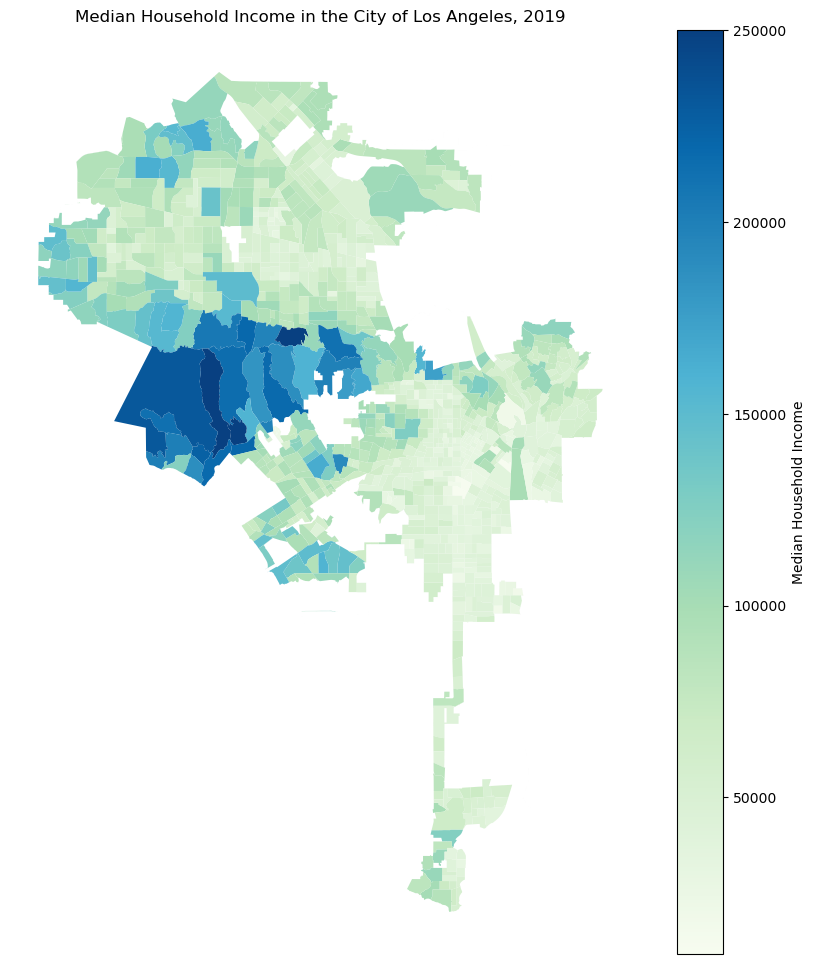

In [23]:
# mapping median household income in City of LA
fig,ax = plt.subplots(figsize=(12,12))

income_tracts.plot(ax=ax,column='Median Income',legend=True,cmap='GnBu',
             legend_kwds={"label": "Median Household Income", "orientation": "vertical"})

ax.axis('off')
ax.set_title('Median Household Income in the City of Los Angeles, 2019')
plt.savefig('Final Median Income Map_alone.png', transparent=True)

### Mapping TIMS Data & Income Data

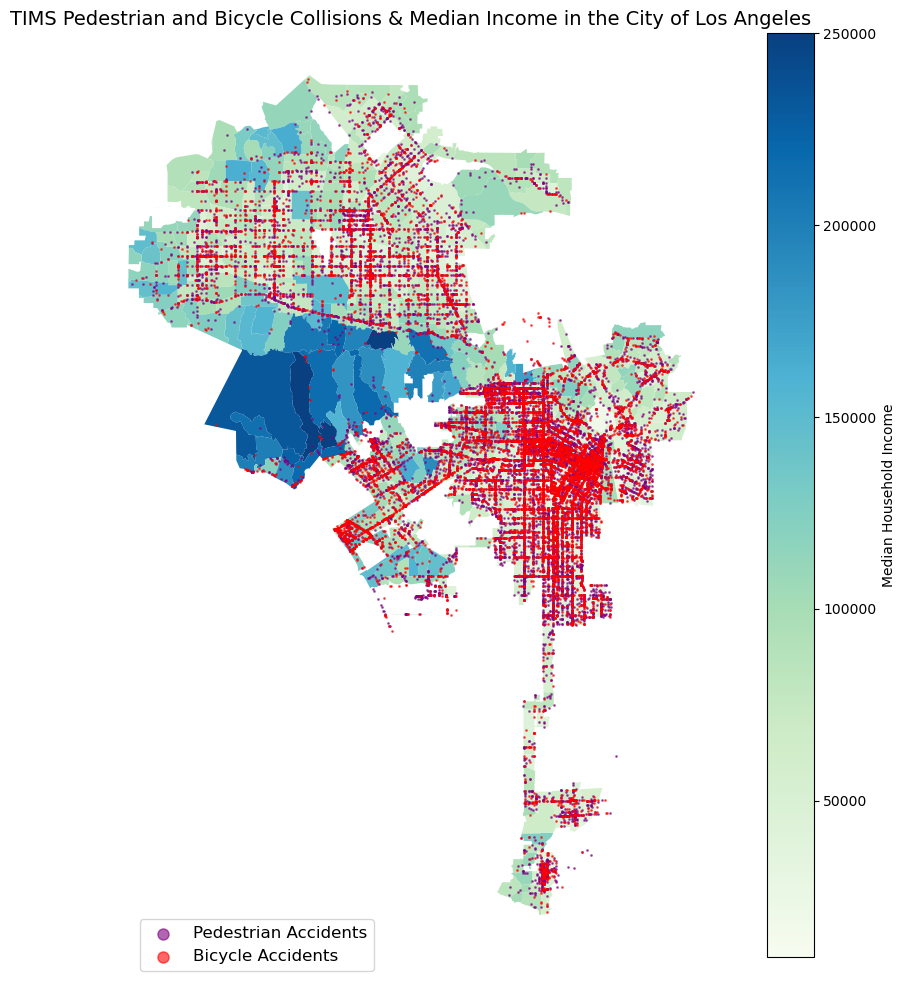

In [24]:
# mapping TIMS and Income Data on one map 
fig,ax = plt.subplots(figsize=(12,12))

income_tracts.plot(ax=ax,column='Median Income',legend=True,cmap='GnBu',
             legend_kwds={"label": "Median Household Income", "orientation": "vertical"})   

ped.plot(ax=ax, color='purple', markersize=1, alpha=0.6, label='Pedestrian Accidents')

bike.plot(ax=ax, color='red', markersize=1, alpha=0.6, label='Bicycle Accidents')

ax.legend(fontsize=12, loc="upper left", markerscale=8.,bbox_to_anchor=(0.05, 0.05))

ax.axis('off')
ax.set_title('TIMS Pedestrian and Bicycle Collisions & Median Income in the City of Los Angeles', fontsize= 14)
plt.savefig('Final Median Income Map_TIMS.png', transparent=True)

### Top 15 Census Tracts with Most Collisions per 1,000 People

In [25]:
#joining census tracts and pedestrian/bike collisions
if 'index_right' in pedbike_la.columns:
    pedbike_la = pedbike_la.rename(columns={'index_right': 'index_collisions'}) #renaming exisitng index to avoid error message

#crs
la_tracts = la_tracts.to_crs('EPSG:4326')
pedbike_la = pedbike_la.to_crs('EPSG:4326')

collisions_tracts = gpd.sjoin(la_tracts,pedbike_la, how='left')

In [26]:
# creating new dataframe for pedestian/bike collision by census tract
collision_by_cs = collisions_tracts.FIPS.value_counts().rename_axis('FIPS').reset_index(name='Total Collision Count')
collision_by_cs

,FIPS,Total Collision Count
0,06037226002,366
1,06037207710,249
2,06037206300,178
3,06037207900,169
4,06037980028,161
...,...,...
1163,06037930101,1
1164,06037930200,1
1165,06037980001,1
1166,06037980002,1


In [27]:
# these are the census tracts with the most pedestrian/bike collisions
collision_by_cs.head(15)

,FIPS,Total Collision Count
0,06037226002,366
1,06037207710,249
2,06037206300,178
3,06037207900,169
4,06037980028,161
5,06037206200,154
6,06037224020,151
7,06037296600,148
8,06037224700,134
9,06037207301,131


In [28]:
# merging census tracts with pedestrian/bike collisions 
pedbike_bytract = pop_tracts.merge(collision_by_cs,on='FIPS')

In [29]:
# verifying that both dataframes merged together
pedbike_bytract.head(10)

,FIPS,Total Population,geometry,Total Collision Count
0,06037101110,4283,"POLYGON ((-2019033.589 -124429.155, -2018948.5...",9
1,06037101122,3405,"POLYGON ((-2017297.948 -125225.326, -2017305.0...",3
2,06037101210,6347,"POLYGON ((-2018157.786 -125480.623, -2018189.7...",15
3,06037101220,3702,"POLYGON ((-2018074.028 -125501.322, -2018030.5...",8
4,06037101300,3884,"POLYGON ((-2016412.468 -126301.385, -2016412.4...",7
5,06037101400,3458,"POLYGON ((-2019358.042 -125184.249, -2019259.9...",12
6,06037102103,1763,"POLYGON ((-2024044.05 -127523.175, -2024057.75...",8
7,06037102104,3721,"POLYGON ((-2023667.159 -128027.268, -2023694.7...",2
8,06037102105,1905,"POLYGON ((-2024516.436 -129630.621, -2024530.3...",1
9,06037102107,4349,"POLYGON ((-2021976.932 -124132.558, -2021973.7...",11


In [30]:
# new column "collisions_per_1000" - the rate of fatal and severe injury pedestrian/bike collisions
pedbike_bytract['collision_per_1000'] = pedbike_bytract['Total Collision Count']/pedbike_bytract['Total Population']*1000

In [31]:
# verifying that both dataframes merged together
pedbike_bytract.head(10)

,FIPS,Total Population,geometry,Total Collision Count,collision_per_1000
0,06037101110,4283,"POLYGON ((-2019033.589 -124429.155, -2018948.5...",9,2.101331
1,06037101122,3405,"POLYGON ((-2017297.948 -125225.326, -2017305.0...",3,0.881057
2,06037101210,6347,"POLYGON ((-2018157.786 -125480.623, -2018189.7...",15,2.363321
3,06037101220,3702,"POLYGON ((-2018074.028 -125501.322, -2018030.5...",8,2.160994
4,06037101300,3884,"POLYGON ((-2016412.468 -126301.385, -2016412.4...",7,1.802266
5,06037101400,3458,"POLYGON ((-2019358.042 -125184.249, -2019259.9...",12,3.470214
6,06037102103,1763,"POLYGON ((-2024044.05 -127523.175, -2024057.75...",8,4.537720
7,06037102104,3721,"POLYGON ((-2023667.159 -128027.268, -2023694.7...",2,0.537490
8,06037102105,1905,"POLYGON ((-2024516.436 -129630.621, -2024530.3...",1,0.524934
9,06037102107,4349,"POLYGON ((-2021976.932 -124132.558, -2021973.7...",11,2.529317


In [32]:
#had to add this line of code since the geomtery column was not reading
pedbike_bytract = gpd.GeoDataFrame(pedbike_bytract, geometry='geometry')

In [33]:
# add this line for basemap to show
pedbike_bytract = pedbike_bytract.to_crs(epsg=3857)

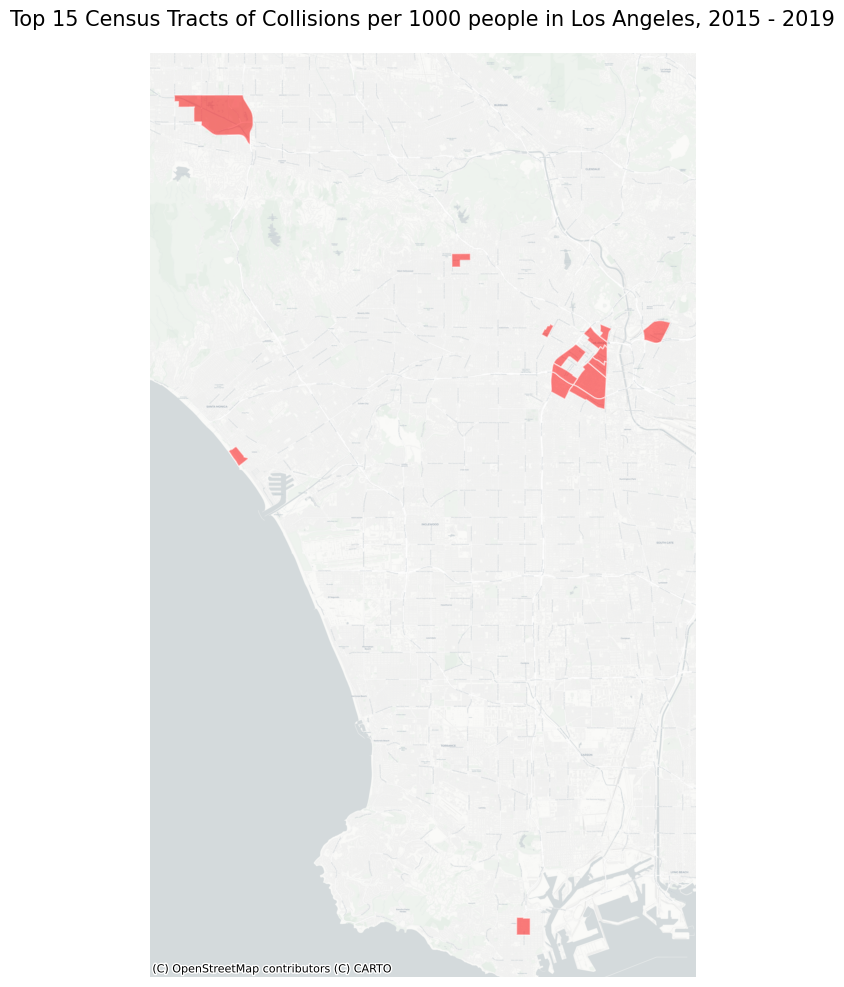

In [34]:
# seeing the location of the top 10 places folks are killed 
fig,ax = plt.subplots(figsize=(12,12))
pedbike_bytract.sort_values(by='collision_per_1000',ascending=False)[:15].plot(ax=ax,
                                                                 color='red',
                                                                 edgecolor='white',
                                                                 alpha=0.5)


# title
ax.set_title('Top 15 Census Tracts of Collisions per 1000 people in Los Angeles, 2015 - 2019',fontsize=15,pad=20)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax, zoom=14, source=ctx.providers.CartoDB.Positron)

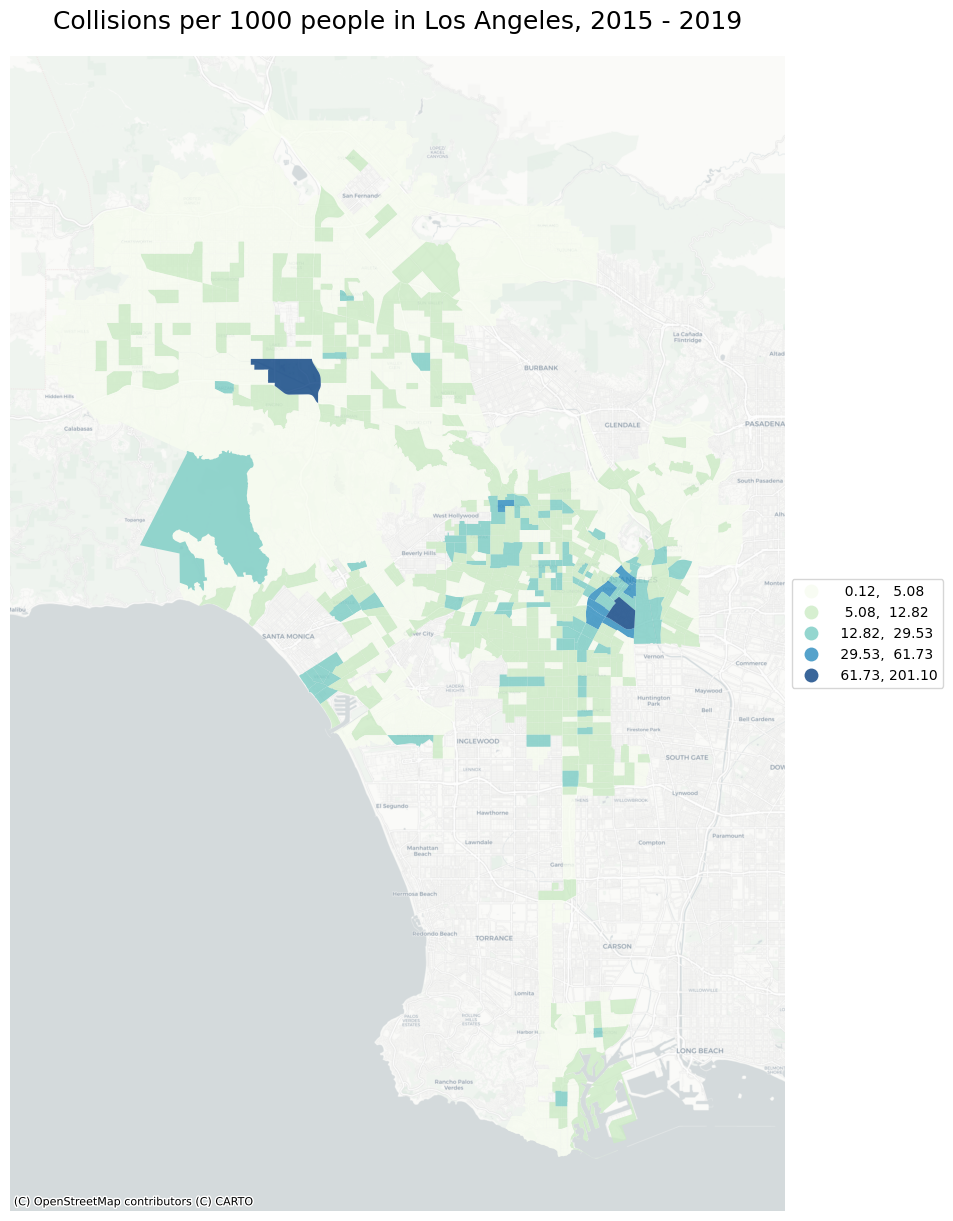

In [35]:
# using natural breaks for choropleth map 
fig,ax = plt.subplots(figsize=(15,15))

pedbike_bytract.plot(ax=ax,  
        column='collision_per_1000',
        legend=True,
        alpha=0.8,    
        cmap='GnBu', 
        scheme='naturalbreaks',
        legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5)})

ax.axis('off')
ax.set_title('Collisions per 1000 people in Los Angeles, 2015 - 2019',fontsize=18,pad=20)
ctx.add_basemap(ax, zoom= 12,source=ctx.providers.CartoDB.Positron)

In [38]:
# creating interactive map of the same data presented above
pedbike_bytract.explore(column='collision_per_1000', 
        legend=True,
        cmap='GnBu', 
        scheme='naturalbreaks',
        tiles='CartoDB positron',
        style_kwds={
            'weight':0.5,
            'color':'black',
            'opacity':0.5
        })

In [37]:
#this are the census tracts with most collisions per 1,000
sorted_pedbike_bytract = pedbike_bytract.sort_values(by='collision_per_1000', ascending=False)
sorted_pedbike_bytract.head(15)

,FIPS,Total Population,geometry,Total Collision Count,collision_per_1000
702,06037226002,1820,"POLYGON ((-13162261.931 4033499.971, -13162283...",366,201.098901
1146,06037980024,223,"POLYGON ((-13192455.041 4053888.365, -13192239...",38,170.403587
542,06037207400,1539,"POLYGON ((-13162761.548 4036500.813, -13162689...",95,61.728395
693,06037224020,2733,"POLYGON ((-13164642.616 4032982.265, -13164651...",151,55.250640
545,06037207710,4667,"POLYGON ((-13163727.46 4035352.957, -13163875....",249,53.353332
692,06037224010,2845,"POLYGON ((-13165535.084 4034261.677, -13165531...",122,42.882250
701,06037226001,2615,"POLYGON ((-13162332.499 4032100.982, -13162333...",102,39.005736
535,06037206200,4001,"POLYGON ((-13162198.268 4035661.185, -13162200...",154,38.490377
421,06037190700,2685,"POLYGON ((-13172806.033 4042449.604, -13172711...",88,32.774674
907,06037273402,2641,"POLYGON ((-13188092.413 4027705.564, -13188106...",78,29.534267
